In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report,roc_auc_score,
    roc_curve, auc, f1_score, precision_recall_curve
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


In [8]:
data_folder = r"C:\Users\erik-\OneDrive\Documentos\GitHub\DETECCION-DE-ANOMALIAS\processed_data"

train_file = os.path.join(data_folder, "unsw_train_stratified.csv")
test_file = os.path.join(data_folder, "unsw_test_stratified.csv")

print("\n--- Cargando conjuntos de datos desde GitHub ---")
train_df = pd.read_csv(train_file, index_col="time", parse_dates=True)
test_df = pd.read_csv(test_file, index_col="time", parse_dates=True)

print(f"➔ TRAIN de entrada: {train_df.shape} | Alertas futuras: {(train_df['Label'] == 1).sum():,} ({100*(train_df['Label'] == 1).sum()/len(train_df):.2f}%)")
print(f"➔ TEST de entrada:  {test_df.shape} | Alertas futuras: {(test_df['Label'] == 1).sum():,} ({100*(test_df['Label'] == 1).sum()/len(test_df):.2f}%)")


--- Cargando conjuntos de datos desde GitHub ---
➔ TRAIN de entrada: (1634343, 22) | Alertas futuras: 33,405 (2.04%)
➔ TEST de entrada:  (700434, 22) | Alertas futuras: 14,317 (2.04%)


In [9]:
features = [col for col in train_df.columns if col not in ["Label", "Label_Actual", "attack_cat"]]

X_train_raw = train_df[features].values
y_train_raw = train_df["Label"].values

X_test_raw = test_df[features].values
y_test_raw = test_df["Label"].values

def create_sequences_horizon(X, y, time_steps=10):
    """
    Agrupa las ventanas en bloques 3D continuos para que la LSTM analice el contexto recente.
    """
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i : i + time_steps])
        # Asociamos el valor predictivo futuro correspondiente a la última ventana del bloque
        y_seq.append(y[i + time_steps - 1])
    return np.array(X_seq), np.array(y_seq)

In [10]:
TIME_STEPS = 10

print(f"\n--- Construyendo secuencias temporales 3D (Pasos: {TIME_STEPS}) ---")
X_train, y_train = create_sequences_horizon(X_train_raw, y_train_raw, time_steps=TIME_STEPS)
X_test, y_test   = create_sequences_horizon(X_test_raw, y_test_raw, time_steps=TIME_STEPS)

print(f"➔ X_train Tensor Shape: {X_train.shape} -> [muestras, time_steps, features]")
print(f"➔ X_test Tensor Shape:  {X_test.shape}")


--- Construyendo secuencias temporales 3D (Pasos: 10) ---
➔ X_train Tensor Shape: (1634333, 10, 19) -> [muestras, time_steps, features]
➔ X_test Tensor Shape:  (700424, 10, 19)


In [11]:
print("\n--- Calculando pesos de clase para mitigar el desbalanceo (2.04%) ---")
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {int(i): float(w) for i, w in enumerate(weights)}
print(f"   Clase 0 (Estable):           {class_weight_dict[0]:.4f}")
print(f"   Clase 1 (Peligro Inminente):  {class_weight_dict[1]:.4f}")


--- Calculando pesos de clase para mitigar el desbalanceo (2.04%) ---
   Clase 0 (Estable):           0.5104
   Clase 1 (Peligro Inminente):  24.4624


In [12]:
num_features = X_train.shape[2]
print(f"\n--- Construyendo Arquitectura del Stacked LSTM ({TIME_STEPS}x{num_features}) ---")

model = Sequential([
    # Primera Capa Recrente (Debe retornar secuencias para alimentar la siguiente)
    LSTM(64, input_shape=(TIME_STEPS, num_features), return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),
    
    # Segunda Capa Recurrente (Stacked)
    LSTM(32, return_sequences=False),
    BatchNormalization(),
    Dropout(0.2),
    
    # Capa Densa de procesamiento de firmas
    Dense(16, activation='relu'),
    
    # Salida Binaria con activación Sigmoide (Probabilidad de peligro inminente)
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.AUC(name='auc', curve='ROC'),
        tf.keras.metrics.AUC(name='pr_auc', curve='PR')
    ]
)

model.summary()


--- Construyendo Arquitectura del Stacked LSTM (10x19) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,849 (136.13 KB)

 Trainable params: 34,657 (135.38 KB)

 Non-trainable params: 192 (768.00 B)

In [13]:
print("\n--- Iniciando fase de entrenamiento del Stacked LSTM Predictivo ---")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,       # Reserva 20% interno de validación balanceada
    epochs=15,                  # 15 épocas estables para convergencia
    batch_size=512,             # Procesamiento masivo eficiente por lotes
    class_weight=class_weight_dict, # Inyección de pesos contra el desbalanceo
    shuffle=True,               # Mezclar los lotes 3D entre épocas
    verbose=1
)


--- Iniciando fase de entrenamiento del Stacked LSTM Predictivo ---
Epoch 1/15
2554/2554 ━━━━━━━━━━━━━━━━━━━━ 71s 26ms/step - accuracy: 0.9818 - auc: 0.9954 - loss: 0.0498 - pr_auc: 0.8225 - val_accuracy: 0.9839 - val_auc: 0.9957 - val_loss: 0.0480 - val_pr_auc: 0.8552
Epoch 2/15
2554/2554 ━━━━━━━━━━━━━━━━━━━━ 101s 40ms/step - accuracy: 0.9838 - auc: 0.9956 - loss: 0.0417 - pr_auc: 0.8410 - val_accuracy: 0.9839 - val_auc: 0.9956 - val_loss: 0.0550 - val_pr_auc: 0.8508
Epoch 3/15
2554/2554 ━━━━━━━━━━━━━━━━━━━━ 66s 26ms/step - accuracy: 0.9839 - auc: 0.9956 - loss: 0.0415 - pr_auc: 0.8418 - val_accuracy: 0.9839 - val_auc: 0.9957 - val_loss: 0.0541 - val_pr_auc: 0.8540
Epoch 4/15
2554/2554 ━━━━━━━━━━━━━━━━━━━━ 91s 35ms/step - accuracy: 0.9839 - auc: 0.9957 - loss: 0.0410 - pr_auc: 0.8430 - val_accuracy: 0.9839 - val_auc: 0.9957 - val_loss: 0.0526 - val_pr_auc: 0.8547
Epoch 5/15
2554/2554 ━━━━━━━━━━━━━━━━━━━━ 95s 37ms/step - accuracy: 0.9839 - auc: 0.9957 - loss: 0.0411 - pr_auc: 0.8424 -


Evaluando rendimiento en el conjunto de TEST externo
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step

ROC-AUC SCORE TOTAL EN TEST: 0.9960

Umbral óptimo calculado para alertas tempranas: 0.9482

Reporte de Clasificación del Horizonte Predictivo (5 segundos adelante):
                   precision    recall  f1-score   support

          Estable       1.00      0.98      0.99    686107
Peligro Inminente       0.57      0.97      0.72     14317

         accuracy                           0.98    700424
        macro avg       0.79      0.98      0.86    700424
     weighted avg       0.99      0.98      0.99    700424



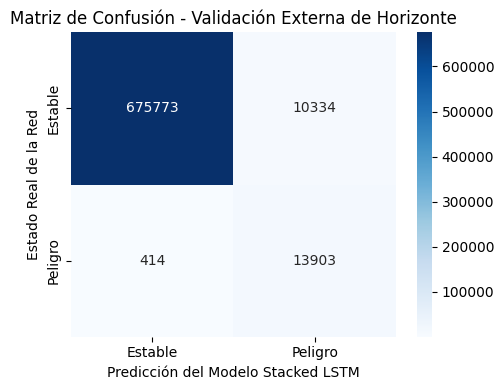

In [16]:
print("\nEvaluando rendimiento en el conjunto de TEST externo")
y_pred_prob = model.predict(X_test, batch_size=512).ravel()

# Calcular el ROC-AUC score definitivo
auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"\nROC-AUC SCORE TOTAL EN TEST: {auc_score:.4f}")

# Encontrar el umbral óptimo de decisión maximizando la curva Precision-Recall (F1-score geométrico)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
f1_scores = [2 * (p * r) / (p + r + 1e-10) for p, r in zip(precision, recall)]
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

print(f"\nUmbral óptimo calculado para alertas tempranas: {best_threshold:.4f}")
y_pred_labels = (y_pred_prob >= best_threshold).astype(int)

print("\nReporte de Clasificación del Horizonte Predictivo (5 segundos adelante):")
print(classification_report(y_test, y_pred_labels, target_names=["Estable", "Peligro Inminente"]))

# Renderizado de la matriz de confusión analítica
cm = confusion_matrix(y_test, y_pred_labels)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Estable", "Peligro"], 
            yticklabels=["Estable", "Peligro"])
plt.title("Matriz de Confusión - Validación Externa de Horizonte")
plt.ylabel("Estado Real de la Red")
plt.xlabel("Predicción del Modelo Stacked LSTM")
plt.tight_layout()
plt.show()

In [17]:

def predecir_anomalias_estratificado(df_nuevos, modelo, threshold, time_steps, features):
    """
    Predicción utilizando el dataset con horizonte precalculado y estratificado.
    Alinea el contexto tridimensional (TIME_STEPS) con las etiquetas del futuro integradas.
    """
    # 1. Extraer características numéricas directas
    # Nota: El escalamiento (Scaler) ya se aplicó antes de guardar las particiones,
    # o bien puedes pasarlo si requieres re-escalar. Suponiendo datos listos:
    X_raw = df_nuevos[features].values
    y_real = df_nuevos["Label"].values
    
    # 2. Construcción del tensor 3D usando el generador de secuencias exacto del entrenamiento
    X_seq = []
    y_true_seq = []
    
    for i in range(len(X_raw) - time_steps):
        X_seq.append(X_raw[i : i + time_steps])
        y_true_seq.append(y_real[i + time_steps - 1])
        
    seqs = np.array(X_seq, dtype=np.float32)
    y_true_seq = np.array(y_true_seq)

    # 3. Ejecutar inferencia en el Stacked LSTM
    print("Calculando predicciones probabilísticas en el conjunto de Test...")
    probs = modelo.predict(seqs, batch_size=512, verbose=1).ravel()
    preds = (probs >= threshold).astype(int)

    # 4. Construir el DataFrame de resultados alineado
    # Como usamos un desfase inicial por el tamaño de la ventana (TIME_STEPS), 
    # recuperamos los índices/timestamps correspondientes a partir de 'time_steps - 1'
    idx_ajustado = df_nuevos.index[time_steps:]
    
    resultado = pd.DataFrame({
        'timestamp_origen': idx_ajustado,
        'probabilidad': probs,
        'prediccion_modelo': preds,
        'realidad_futura': y_true_seq,
        'clase_predicha': np.where(preds == 1, 'Alerta: Peligro Inminente', 'Estable')
    })

    n_ataques = preds.sum()
    print("\n" + "="*40)
    print(f"Ventanas recurrentes analizadas : {len(preds):,}")
    print(f"Alertas de ataque emitidas     : {n_ataques:,} ({n_ataques/len(preds):.2%})")
    print(f"Eventos reales en el futuro    : {y_true_seq.sum(),} ({y_true_seq.sum()/len(y_true_seq):.2%})")
    print("="*40)
    
    return resultado



resultado_test = predecir_anomalias_estratificado(
    df_nuevos=test_df,
    modelo=model,
    threshold=best_threshold, # Tu valor óptimo: 0.9482
    time_steps=10,            # Tus TIME_STEPS = 10
    features=features         # Lista de características numéricas cargadas
)

print("\nMuestra de las primeras 10 predicciones:")
print(resultado_test.head(10))


Calculando predicciones probabilísticas en el conjunto de Test...
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step

Ventanas recurrentes analizadas : 700,424
Alertas de ataque emitidas     : 24,237 (3.46%)
Eventos reales en el futuro    : (np.int64(14317),) (2.04%)

Muestra de las primeras 10 predicciones:
     timestamp_origen  probabilidad  prediccion_modelo  realidad_futura  \
0 2015-02-02 22:00:04      0.000638                  0                0   
1 2015-02-17 22:45:36      0.000638                  0                0   
2 2015-02-08 13:34:39      0.000638                  0                0   
3 2015-02-17 01:18:05      0.000638                  0                0   
4 2015-01-31 00:03:27      0.000638                  0                0   
5 2015-01-28 12:48:15      0.000638                  0                0   
6 2015-02-13 09:58:40      0.000638                  0                0   
7 2015-02-08 05:07:27      0.000638                  0                0   
8 2015-02-09 08:55:58

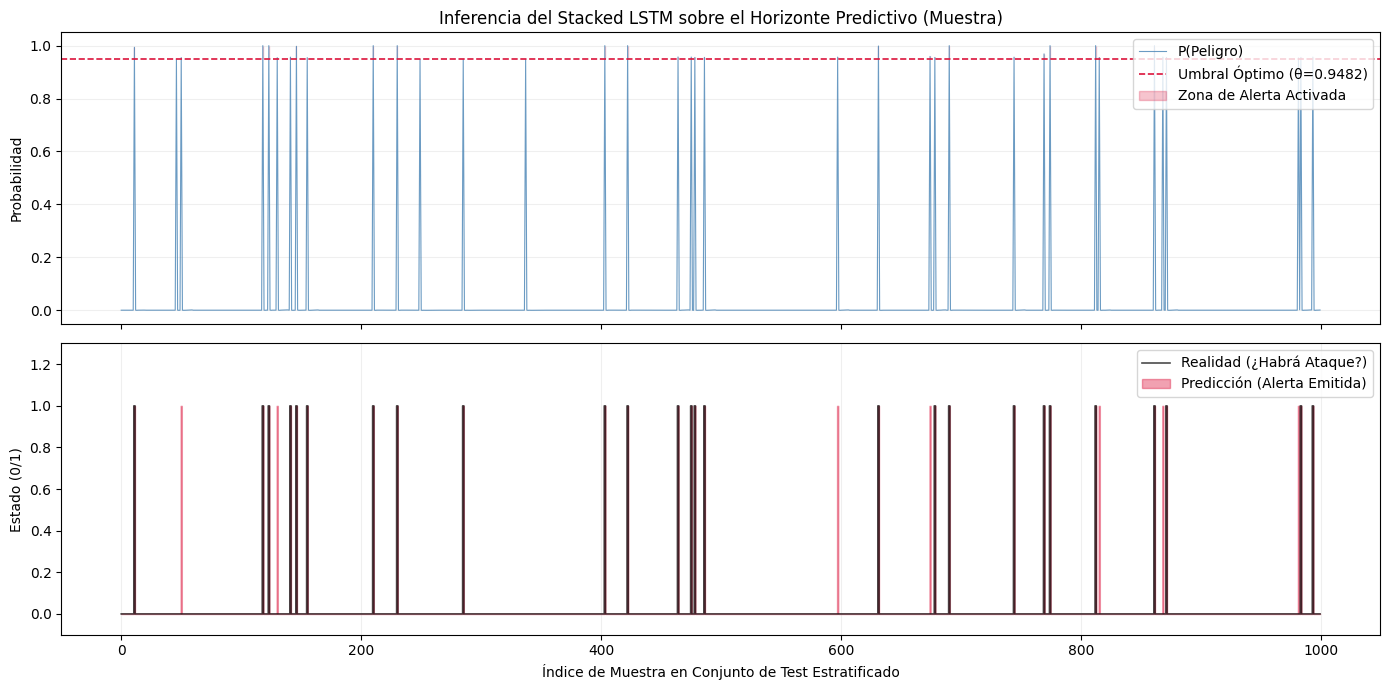


Distribución de las clasificaciones finales del modelo:
clase_predicha
Estable                      676187
Alerta: Peligro Inminente     24237
Name: count, dtype: int64


In [18]:
MUESTRA_GRAFICA = 1000
df_sub = resultado_test.iloc[:MUESTRA_GRAFICA].reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
idx_plot = np.arange(len(df_sub))

# PANEL 1: Probabilidad continua devuelta por la Sigmoide
axes[0].plot(idx_plot, df_sub['probabilidad'], lw=0.8, color='steelblue', alpha=0.8, label='P(Peligro)')
axes[0].axhline(best_threshold, color='crimson', lw=1.2, linestyle='--', label=f'Umbral Óptimo (θ={best_threshold:.4f})')
axes[0].fill_between(idx_plot, df_sub['probabilidad'], best_threshold,
                     where=df_sub['probabilidad'] >= best_threshold,
                     color='crimson', alpha=0.25, label='Zona de Alerta Activada')
axes[0].set_ylabel('Probabilidad')
axes[0].set_title('Inferencia del Stacked LSTM sobre el Horizonte Predictivo (Muestra)')
axes[0].legend(loc='upper right')
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(axis='y', alpha=0.2)

# PANEL 2: Comparativa de Realidad vs Predicción Binaria
# Esto te permite ver visualmente dónde coinciden y dónde ocurren las falsas alarmas (Precision=0.57)
axes[1].step(idx_plot, df_sub['realidad_futura'], color='black', lw=1.2, alpha=0.7, label='Realidad (¿Habrá Ataque?)', where='mid')
axes[1].fill_between(idx_plot, df_sub['prediccion_modelo'], color='crimson', alpha=0.4, step='mid', label='Predicción (Alerta Emitida)')
axes[1].set_ylabel('Estado (0/1)')
axes[1].set_xlabel('Índice de Muestra en Conjunto de Test Estratificado')
axes[1].set_ylim(-0.1, 1.3)
axes[1].legend(loc='upper right')
axes[1].grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

# ── Resumen de Frecuencias de Salida ──────────────────────────────────────────
print("\nDistribución de las clasificaciones finales del modelo:")
print(resultado_test['clase_predicha'].value_counts())